# Distance-Based Delays in Wilson-Cowan Metapopulation Model

This notebook demonstrates how to implement and explore **distance-based inter-node delays** in the Wilson-Cowan metapopulation model.

## Key Concepts

**Standard model**: All inter-node connections have the same delay $\rho$

**Distance-based model**: Each connection has delay based on spatial distance:

$$\rho_{ij} = \rho_{\text{base}} + \frac{d_{ij}}{v_{\text{signal}}}$$

where:
- $d_{ij}$ = Euclidean distance between nodes $i$ and $j$
- $v_{\text{signal}}$ = signal propagation velocity
- $\rho_{\text{base}}$ = baseline synaptic delay

## Notebook Contents

1. **Setup**: Import libraries and create network
2. **Spatial Positioning**: Assign coordinates to nodes
3. **Delay Computation**: Calculate distance-based delays
4. **Visualization**: Plot network and delay matrix
5. **Simulation**: Run Wilson-Cowan dynamics
6. **Parameter Exploration**: Interactive widgets to adjust parameters

---
## 1. Setup and Imports

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add parent directory to path
sys.path.insert(0, os.path.abspath('..'))

# Import our custom modules
from src.network import Network
from src.distance_delays import (
    assign_node_coordinates,
    compute_distance_matrix,
    compute_delay_matrix,
    visualize_network_with_delays
)

# For interactive exploration (optional)
try:
    from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
    WIDGETS_AVAILABLE = True
except ImportError:
    print("ipywidgets not available - install for interactive exploration")
    WIDGETS_AVAILABLE = False

# Matplotlib settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

print("✓ Imports successful")

✓ Imports successful


---
## 2. Create Network with Spatial Positions

First, we create a network and assign spatial coordinates to each node based on the topology.

In [2]:
# ============================================================
# ADJUST THESE PARAMETERS
# ============================================================

# Network configuration
network_config = {
    'N': 16,              # Number of nodes
    'topology': 'ring',   # Options: 'line', 'ring', 'lattice', 'full', 'smallworld'
    'p': 0.2,            # For ring/smallworld: proportion of neighbors
    'rewire_prob': 0.05  # For smallworld: rewiring probability
}

# Spatial positioning
spatial_scale = 1.0  # Scale factor for node spacing

# ============================================================

# Create the network
network = Network(network_config)
print(f"Created {network_config['topology']} network with {network_config['N']} nodes")

# Assign spatial positions
positions = assign_node_coordinates(
    network,
    topology=network_config['topology'],
    scale=spatial_scale
)

print(f"Assigned spatial positions with scale={spatial_scale}")
print(f"Sample positions: Node 0 at {positions[0]}, Node 1 at {positions[1]}")

Created ring network with 16 nodes
Assigned spatial positions with scale=1.0
Sample positions: Node 0 at (np.float64(2.5464790894703255), np.float64(0.0)), Node 1 at (np.float64(2.3526399107296116), np.float64(0.9744953584044327))


---
## 3. Compute Distance and Delay Matrices

Now we calculate the Euclidean distances between nodes and convert them to time delays.

In [3]:
# ============================================================
# ADJUST THESE PARAMETERS TO CHANGE DELAYS
# ============================================================

signal_velocity = 2.0   # Signal propagation speed [distance/time]
                        # INCREASE → shorter delays (faster)
                        # DECREASE → longer delays (slower)

base_delay = 0.5       # Baseline delay added to all connections [time]
                       # Represents synaptic/processing delay

self_delay = 0.0       # Delay for self-connections [time]

max_delay = 50.0       # Maximum allowed delay [time]
                       # Set to None for no limit

# ============================================================

# Compute distance matrix
distance_matrix = compute_distance_matrix(positions)

print("Distance Matrix Statistics:")
non_zero = distance_matrix[distance_matrix > 0]
print(f"  Min distance: {non_zero.min():.3f}")
print(f"  Max distance: {non_zero.max():.3f}")
print(f"  Mean distance: {non_zero.mean():.3f}")

# Compute delay matrix
delay_matrix = compute_delay_matrix(
    positions=positions,
    adjacency_matrix=network.A,
    signal_velocity=signal_velocity,
    base_delay=base_delay,
    self_delay=self_delay,
    max_delay=max_delay
)

print("\nDelay Matrix Statistics:")
connected = delay_matrix[network.A > 0]
connected = connected[connected > 0]
print(f"  Min inter-node delay: {connected.min():.3f}")
print(f"  Max inter-node delay: {connected.max():.3f}")
print(f"  Mean inter-node delay: {connected.mean():.3f}")
print(f"  Number of connections: {len(connected)}")

Distance Matrix Statistics:
  Min distance: 0.994
  Max distance: 5.093
  Mean distance: 3.447

Delay Matrix Statistics:
  Min inter-node delay: 0.997
  Max inter-node delay: 1.915
  Mean inter-node delay: 1.462
  Number of connections: 96


---
## 4. Visualize Network and Delays

Let's visualize:
- **Left panel**: Network graph with nodes at spatial positions (edge colors = delays)
- **Right panel**: Delay matrix heatmap

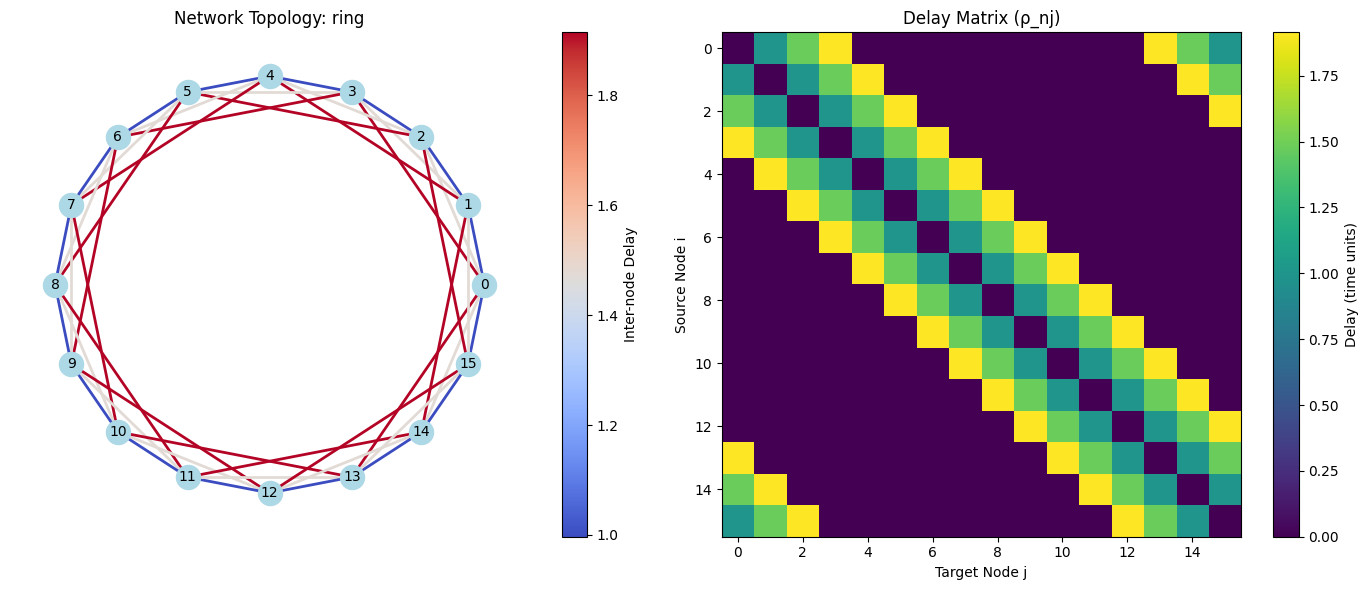

In [4]:
fig, axes = visualize_network_with_delays(
    network=network,
    positions=positions,
    delay_matrix=delay_matrix
)

plt.show()

---
## 5. Run Wilson-Cowan Simulation

Now let's run the full metapopulation model with distance-based delays.

**Note**: The current `model.py` uses a single delay value. We use the **mean delay** as an approximation. To use the full delay matrix, `model.py` would need to be modified to support heterogeneous delays.

In [5]:
from experiments.distance_based_delays import DistanceDelayedMetapopulation

# Create model
model = DistanceDelayedMetapopulation()

# Load config (or create inline)
model.config = {
    'network_params': network_config,
    'distance_delay_params': {
        'enabled': True,
        'signal_velocity': signal_velocity,
        'base_delay': base_delay,
        'self_delay': self_delay,
        'max_delay': max_delay,
        'scale': spatial_scale,
        'layout_seed': 42
    },
    'model_params': {
        'mode': 'wilson_cowan',
        'c_ee': 1.0,
        'c_ei': 1.0,
        'c_ie': -1.0,
        'c_ii': -1.0,
        'tau_1': 1.0,
        'tau_2': 1.4,
        'rho': 10.0,  # Fallback value (will be overridden)
        'beta': 10.0,
        'alpha': 0.6,
        'T_e': 1.0,
        'T_i': 1.0,
        'P': 0.5,
        'Q': 0.5,
        'k': 1.0
    },
    'simulation': {
        'duration': 500,
        'dt': 0.1,
        'initial_conditions': 0.5
    }
}

# Run the experiment
print("Setting up network...")
model.create_network_with_positions()

print("Computing delays...")
model.compute_delay_matrix()

print("Initializing model...")
model.initialise_model_with_delays()

print("Running simulation...")
model.run_simulation(timeit=True)

print("\n✓ Simulation complete!")

Setting up network...

Assigning spatial positions for ring topology...
  - Spatial scale: 1.0
  - Assigned positions to 16 nodes
  - Sample positions: Node 0=(np.float64(2.5464790894703255), np.float64(0.0)), Node 1=(np.float64(2.3526399107296116), np.float64(0.9744953584044327))
Computing delays...

Computing distance-based delay matrix...
  - Signal velocity: 2.0 [spatial units / time units]
  - Base delay: 0.5 [time units]
  - Self delay: 0.0 [time units]
  - Max delay cap: 50.0

Delay matrix statistics:
  - Min inter-node delay: 0.997
  - Max inter-node delay: 1.915
  - Mean inter-node delay: 1.462
  - Number of connections: 96
Initializing model...

⚠ MODEL LIMITATION:
  Current model.py uses a single 'rho' value for all connections.
  Using MEAN delay = 1.462 as approximation.
  To use full delay matrix, modify model.py (see TODO in code)
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1.0, 'c_ei': 1.0, 'c_ie': -1.0, 'c_ii': -1.0, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': np.float64

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Simulation runtime: 2.06 seconds

✓ Simulation complete!


### Plot Trajectories

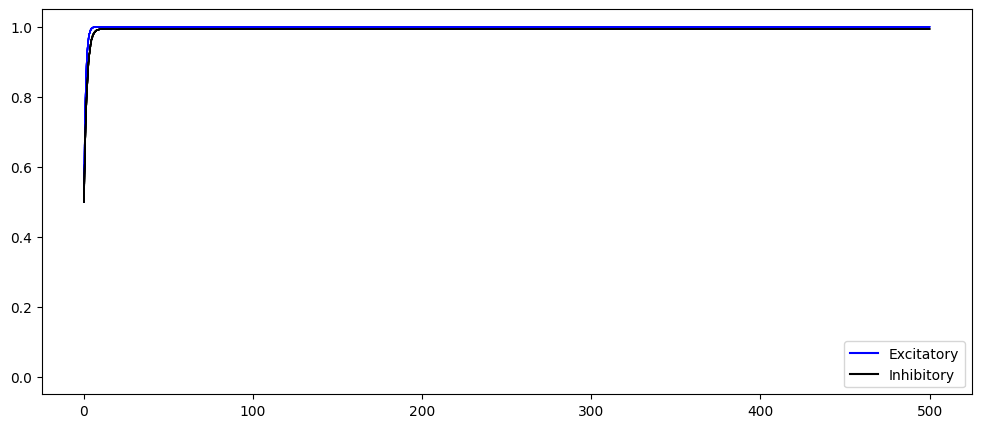

In [6]:
# Plot excitatory and inhibitory populations over time
model.plot_trajectories()

---
## 6. Interactive Parameter Exploration

Use the sliders below to interactively adjust parameters and see how they affect the delay matrix.

**Note**: This requires `ipywidgets` to be installed.

In [7]:
if WIDGETS_AVAILABLE:
    def explore_delays(signal_velocity, base_delay, spatial_scale, topology):
        """
        Interactive function to explore how parameters affect delays.
        
        Adjust sliders to see real-time updates!
        """
        # Create network
        net_config = network_config.copy()
        net_config['topology'] = topology
        net = Network(net_config)
        
        # Get positions
        pos = assign_node_coordinates(net, topology=topology, scale=spatial_scale)
        
        # Compute delays
        delays = compute_delay_matrix(
            positions=pos,
            adjacency_matrix=net.A,
            signal_velocity=signal_velocity,
            base_delay=base_delay,
            max_delay=50.0
        )
        
        # Visualize
        fig, axes = visualize_network_with_delays(net, pos, delays)
        
        # Print statistics
        connected = delays[net.A > 0]
        connected = connected[connected > 0]
        if len(connected) > 0:
            print(f"Delay range: [{connected.min():.2f}, {connected.max():.2f}]")
            print(f"Mean delay: {connected.mean():.2f}")
        
        plt.show()
    
    # Create interactive widget
    interact(
        explore_delays,
        signal_velocity=FloatSlider(min=0.1, max=10.0, step=0.1, value=2.0, 
                                    description='Velocity'),
        base_delay=FloatSlider(min=0.0, max=5.0, step=0.1, value=0.5,
                              description='Base Delay'),
        spatial_scale=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0,
                                 description='Scale'),
        topology=Dropdown(options=['line', 'ring', 'lattice', 'full'],
                         value='ring', description='Topology')
    )
else:
    print("Install ipywidgets for interactive exploration:")
    print("  pip install ipywidgets")

interactive(children=(FloatSlider(value=2.0, description='Velocity', max=10.0, min=0.1), FloatSlider(value=0.5…

---
## 7. Parameter Sweep: Signal Velocity

Let's run multiple simulations with different signal velocities to see how delay magnitude affects dynamics.

In [8]:
# Define velocity values to test
velocities = [0.5, 1.0, 2.0, 5.0, 10.0]

# Store results
results = {}

for vel in velocities:
    print(f"\nRunning with velocity = {vel}...")
    
    # Create fresh model
    m = DistanceDelayedMetapopulation()
    m.config = model.config.copy()  # Use same config as before
    m.config['distance_delay_params']['signal_velocity'] = vel
    
    # Run
    m.create_network_with_positions()
    m.compute_delay_matrix()
    m.initialise_model_with_delays()
    m.run_simulation(timeit=False)
    
    # Store
    results[vel] = {
        'model': m,
        'trajectories': m.model.trajectories,
        'delay_matrix': m.delay_matrix
    }
    
print("\n✓ Parameter sweep complete!")


Running with velocity = 0.5...

Assigning spatial positions for ring topology...
  - Spatial scale: 1.0
  - Assigned positions to 16 nodes
  - Sample positions: Node 0=(np.float64(2.5464790894703255), np.float64(0.0)), Node 1=(np.float64(2.3526399107296116), np.float64(0.9744953584044327))

Computing distance-based delay matrix...
  - Signal velocity: 0.5 [spatial units / time units]
  - Base delay: 0.5 [time units]
  - Self delay: 0.0 [time units]
  - Max delay cap: 50.0

Delay matrix statistics:
  - Min inter-node delay: 2.487
  - Max inter-node delay: 6.159
  - Mean inter-node delay: 4.348
  - Number of connections: 96

⚠ MODEL LIMITATION:
  Current model.py uses a single 'rho' value for all connections.
  Using MEAN delay = 4.348 as approximation.
  To use full delay matrix, modify model.py (see TODO in code)
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1.0, 'c_ei': 1.0, 'c_ie': -1.0, 'c_ii': -1.0, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': np.float64(4.348049020124145), 'beta': 10.

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.

Running with velocity = 1.0...

Assigning spatial positions for ring topology...
  - Spatial scale: 1.0
  - Assigned positions to 16 nodes
  - Sample positions: Node 0=(np.float64(2.5464790894703255), np.float64(0.0)), Node 1=(np.float64(2.3526399107296116), np.float64(0.9744953584044327))

Computing distance-based delay matrix...
  - Signal velocity: 1.0 [spatial units / time units]
  - Base delay: 0.5 [time units]
  - Self delay: 0.0 [time units]
  - Max delay cap: 50.0

Delay matrix statistics:
  - Min inter-node delay: 1.494
  - Max inter-node delay: 3.329
  - Mean inter-node delay: 2.424
  - Number of connections: 96

⚠ MODEL LIMITATION:
  Current model.py uses a single 'rho' value for all connections.
  Using MEAN delay = 2.424 as approximation.
  To use full delay matrix, modify model.py (see TODO in code)
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1.0, 'c_ei': 1.0, 'c_ie': -1.0, 'c_ii': -1.0, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': np.f

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.

Running with velocity = 2.0...

Assigning spatial positions for ring topology...
  - Spatial scale: 1.0
  - Assigned positions to 16 nodes
  - Sample positions: Node 0=(np.float64(2.5464790894703255), np.float64(0.0)), Node 1=(np.float64(2.3526399107296116), np.float64(0.9744953584044327))

Computing distance-based delay matrix...
  - Signal velocity: 2.0 [spatial units / time units]
  - Base delay: 0.5 [time units]
  - Self delay: 0.0 [time units]
  - Max delay cap: 50.0

Delay matrix statistics:
  - Min inter-node delay: 0.997
  - Max inter-node delay: 1.915
  - Mean inter-node delay: 1.462
  - Number of connections: 96

⚠ MODEL LIMITATION:
  Current model.py uses a single 'rho' value for all connections.
  Using MEAN delay = 1.462 as approximation.
  To use full delay matrix, modify model.py (see TODO in code)
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1.0, 'c_ei': 1.0, 'c_ie': -1.0, 'c_ii': -1.0, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': np.f

...

Using default integration parameters.

Running with velocity = 5.0...

Assigning spatial positions for ring topology...
  - Spatial scale: 1.0
  - Assigned positions to 16 nodes
  - Sample positions: Node 0=(np.float64(2.5464790894703255), np.float64(0.0)), Node 1=(np.float64(2.3526399107296116), np.float64(0.9744953584044327))

Computing distance-based delay matrix...
  - Signal velocity: 5.0 [spatial units / time units]
  - Base delay: 0.5 [time units]
  - Self delay: 0.0 [time units]
  - Max delay cap: 50.0

Delay matrix statistics:
  - Min inter-node delay: 0.699
  - Max inter-node delay: 1.066
  - Mean inter-node delay: 0.885
  - Number of connections: 96

⚠ MODEL LIMITATION:
  Current model.py uses a single 'rho' value for all connections.
  Using MEAN delay = 0.885 as approximation.
  To use full delay matrix, modify model.py (see TODO in code)
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1.0, 'c_ei': 1.0, 'c_ie': -1.0, 'c_ii': -1.0, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': np.f

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.

Running with velocity = 10.0...

Assigning spatial positions for ring topology...
  - Spatial scale: 1.0
  - Assigned positions to 16 nodes
  - Sample positions: Node 0=(np.float64(2.5464790894703255), np.float64(0.0)), Node 1=(np.float64(2.3526399107296116), np.float64(0.9744953584044327))

Computing distance-based delay matrix...
  - Signal velocity: 10.0 [spatial units / time units]
  - Base delay: 0.5 [time units]
  - Self delay: 0.0 [time units]
  - Max delay cap: 50.0

Delay matrix statistics:
  - Min inter-node delay: 0.599
  - Max inter-node delay: 0.783
  - Mean inter-node delay: 0.692
  - Number of connections: 96

⚠ MODEL LIMITATION:
  Current model.py uses a single 'rho' value for all connections.
  Using MEAN delay = 0.692 as approximation.
  To use full delay matrix, modify model.py (see TODO in code)
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1.0, 'c_ei': 1.0, 'c_ie': -1.0, 'c_ii': -1.0, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': np

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.

✓ Parameter sweep complete!


### Compare Trajectories Across Velocities

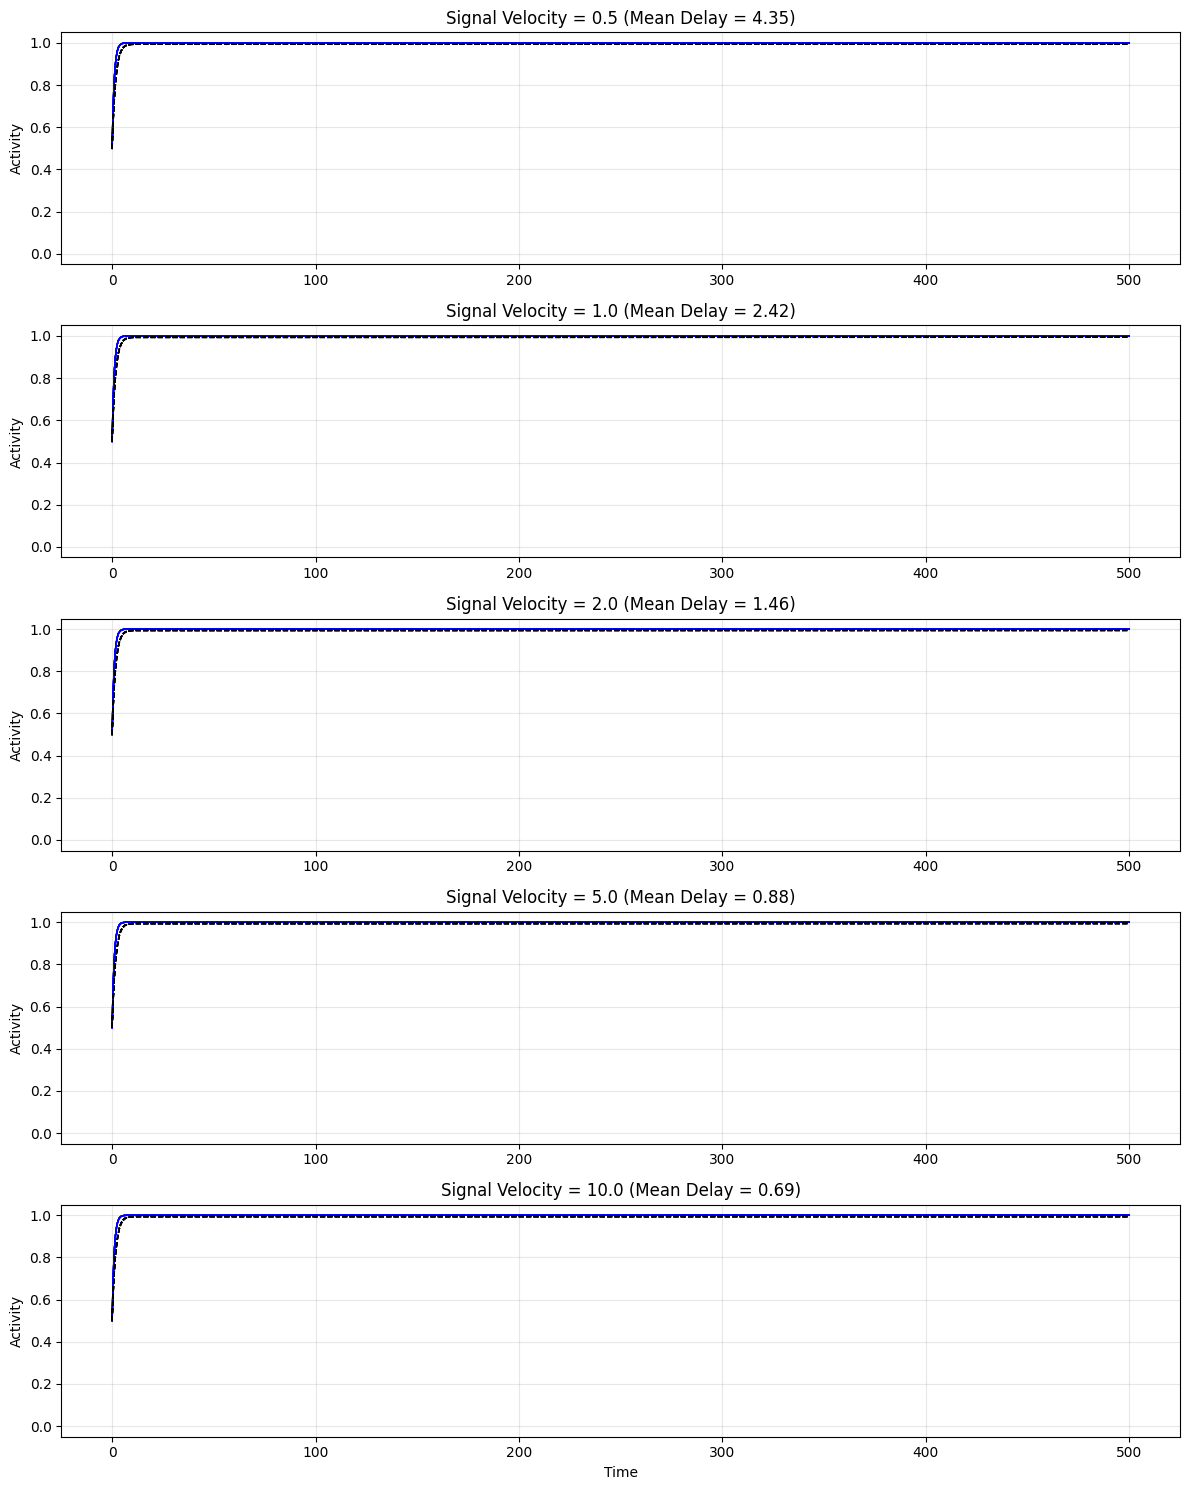

In [9]:
# Plot comparison
fig, axes = plt.subplots(len(velocities), 1, figsize=(12, 3*len(velocities)))

for idx, vel in enumerate(velocities):
    traj = results[vel]['trajectories']
    t = results[vel]['model'].model.time_array
    
    # Plot excitatory populations (blue)
    axes[idx].plot(t, traj[0].T, color='blue', alpha=0.5, linewidth=1)
    
    # Plot inhibitory populations (black, dashed)
    axes[idx].plot(t, traj[1].T, color='black', alpha=0.5, linewidth=1, linestyle='--')
    
    axes[idx].set_title(f"Signal Velocity = {vel} (Mean Delay = {results[vel]['delay_matrix'][network.A > 0].mean():.2f})")
    axes[idx].set_ylabel("Activity")
    axes[idx].set_ylim(-0.05, 1.05)
    axes[idx].grid(alpha=0.3)
    
    if idx == len(velocities) - 1:
        axes[idx].set_xlabel("Time")

plt.tight_layout()
plt.show()

---
## Summary and Next Steps

### What We've Learned

1. **Spatial positioning**: Network topology determines node positions
2. **Distance calculation**: Euclidean distance between all node pairs
3. **Delay computation**: `delay = base + distance / velocity`
4. **Parameter effects**:
   - Higher velocity → shorter delays → faster communication
   - Higher spatial scale → larger distances → longer delays
   - Network topology affects distance distribution

### Key Parameters to Explore

**To change delay magnitude**:
- `signal_velocity`: Primary control (higher = shorter delays)
- `base_delay`: Adds constant offset to all delays
- `spatial_scale`: Scales all distances uniformly

**To change network structure**:
- `topology`: Different spatial arrangements
- `N`: Number of nodes
- `k` (coupling strength): How strongly nodes interact

### Future Extensions

1. **Heterogeneous intra-node delays**: Make τ₁, τ₂ vary by node
2. **Modify model.py**: Support full delay matrix (not just mean)
3. **Adaptive delays**: Time-varying or activity-dependent delays
4. **Real brain connectivity**: Use empirical connectome data
5. **Analysis tools**: Synchronization measures, frequency analysis

### Where to Change Values

- **In this notebook**: Cells marked with "ADJUST THESE PARAMETERS"
- **Config file**: `experiments/distance_based_delays.yaml`
- **Python script**: `experiments/distance_based_delays.py`
- **Core module**: `src/distance_delays.py` (advanced)